# (12) FashionMNIST: (16, 8.0/16.0/32.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

Lienar decoder + MNIST works?

Being fit on fit_1

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## (16, 32.0)

In [3]:
a = 'poisson_FashionMNIST_t-16_z-[512]_u-10,du-10_<grad|lin>_seed-1'
b = 'b100-ep400-lr(3e-05)_beta(32:0.1)_temp(0.01:0.5)_gr(1000)_(2025_03_13,13:14)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

400

In [4]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0298], device='cuda:1', grad_fn=<ExpBackward0>),)

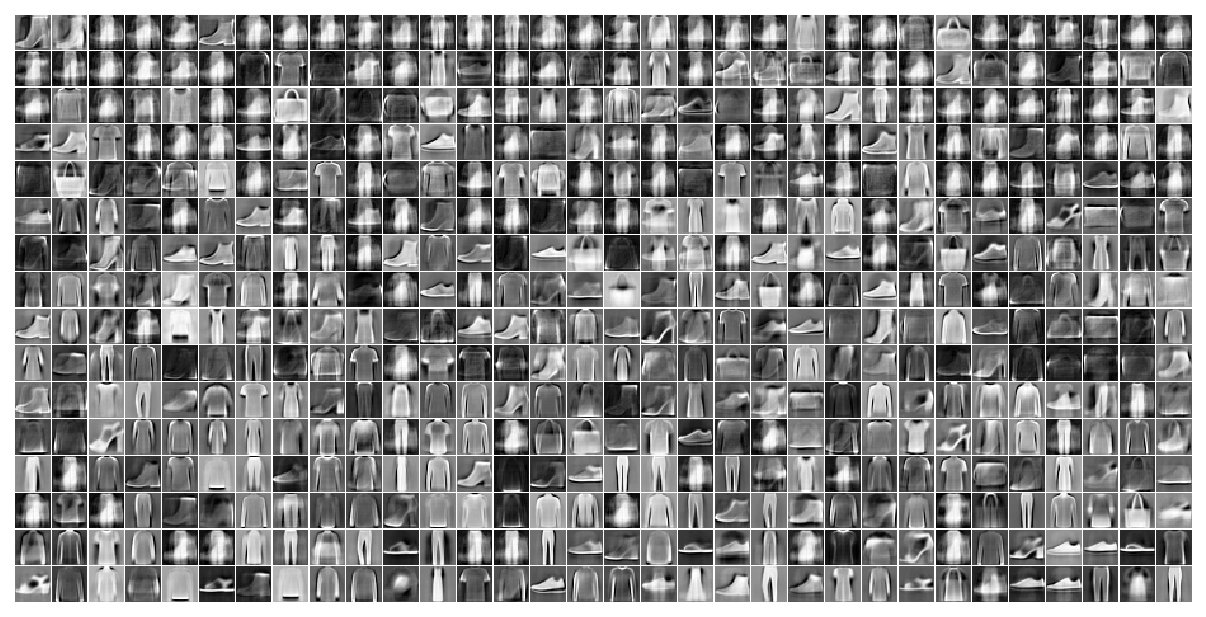

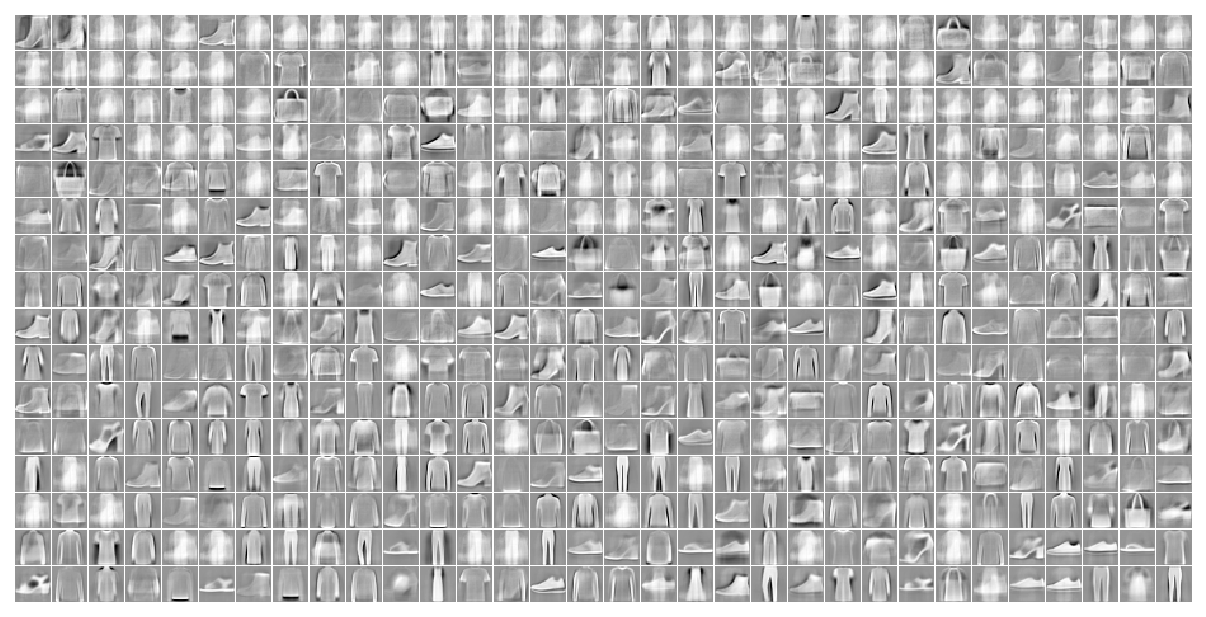

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [02:16<00:00, 68.30s/it]


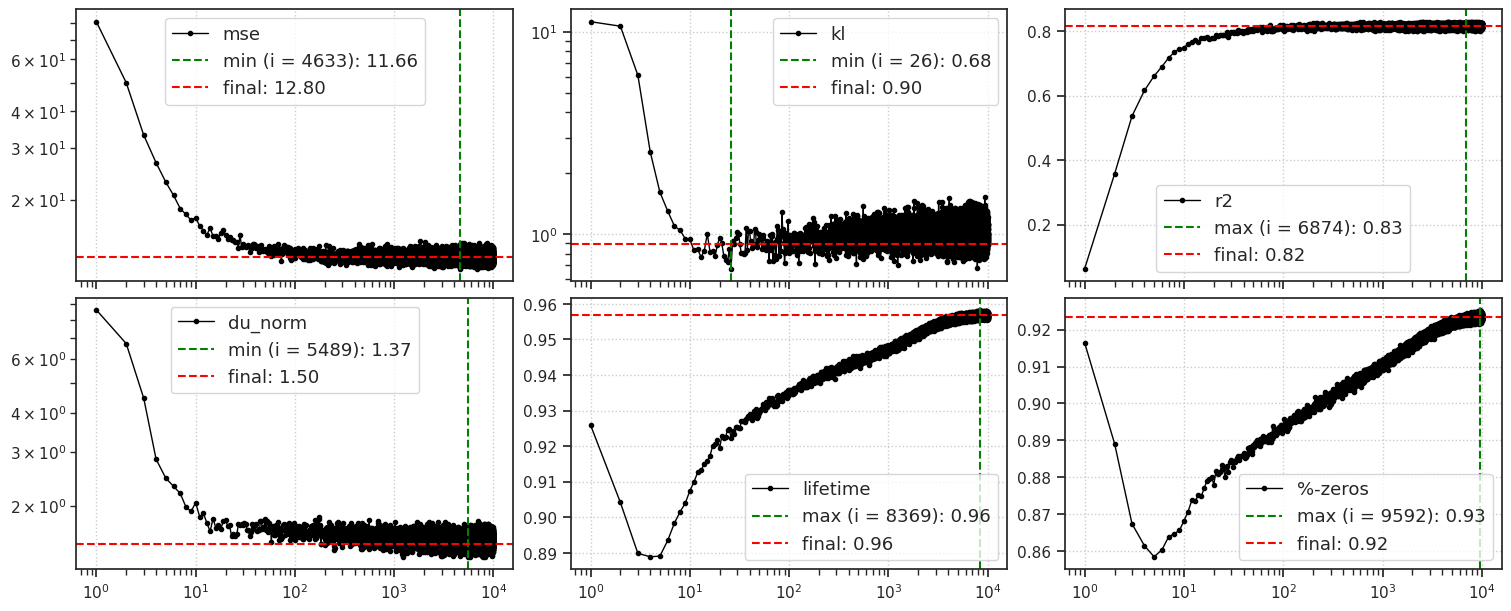

CPU times: user 2min 11s, sys: 5.13 s, total: 2min 16s
Wall time: 2min 29s


In [6]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [7]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:06<00:00,  3.00s/it]


In [8]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [10]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [11]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.86

## (16, 16.0)

In [12]:
a = 'poisson_FashionMNIST_t-16_z-[512]_u-10,du-10_<grad|lin>_seed-1'
b = 'b100-ep400-lr(3e-05)_beta(16:0.1)_temp(0.01:0.5)_gr(1000)_(2025_03_13,13:12)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

400

In [13]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0368], device='cuda:1', grad_fn=<ExpBackward0>),)

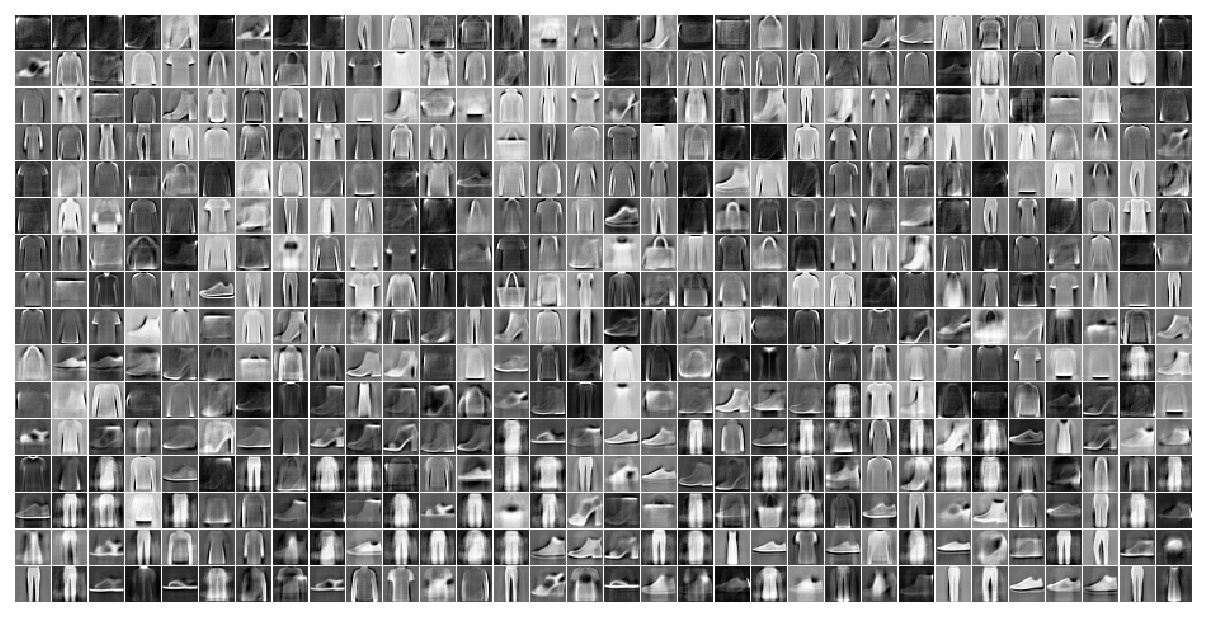

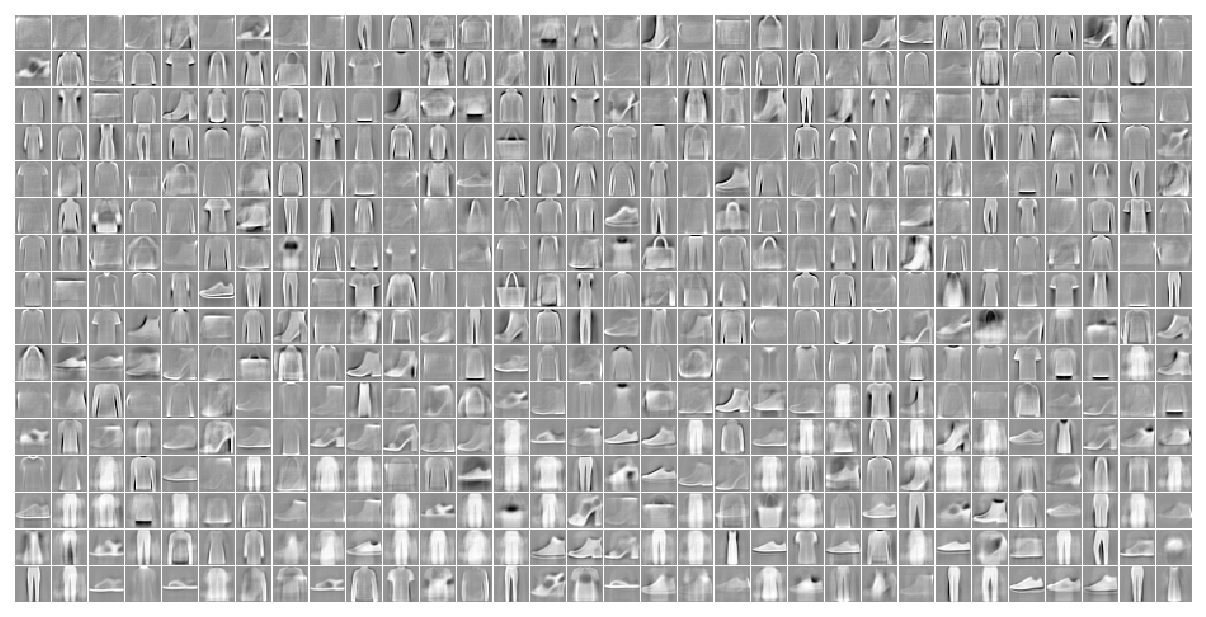

In [14]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:55<00:00, 27.98s/it]


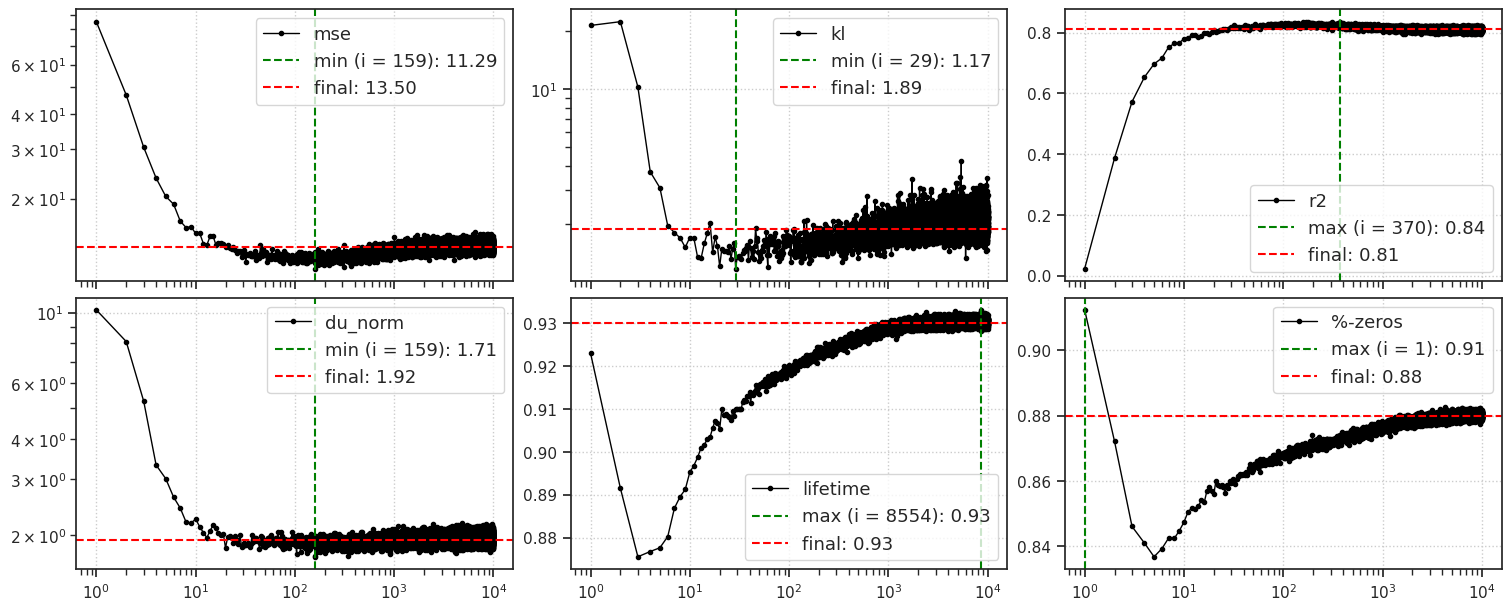

CPU times: user 1min 4s, sys: 4.14 s, total: 1min 8s
Wall time: 1min 8s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [16]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:05<00:00,  2.95s/it]


In [17]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [19]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [20]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.8608

## (16, 8.0)

In [21]:
a = 'poisson_FashionMNIST_t-16_z-[512]_u-10,du-10_<grad|lin>_seed-1'
b = 'b100-ep400-lr(3e-05)_beta(8:0.1)_temp(0.01:0.5)_gr(1000)_(2025_03_13,13:58)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

400

In [22]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0483], device='cuda:1', grad_fn=<ExpBackward0>),)

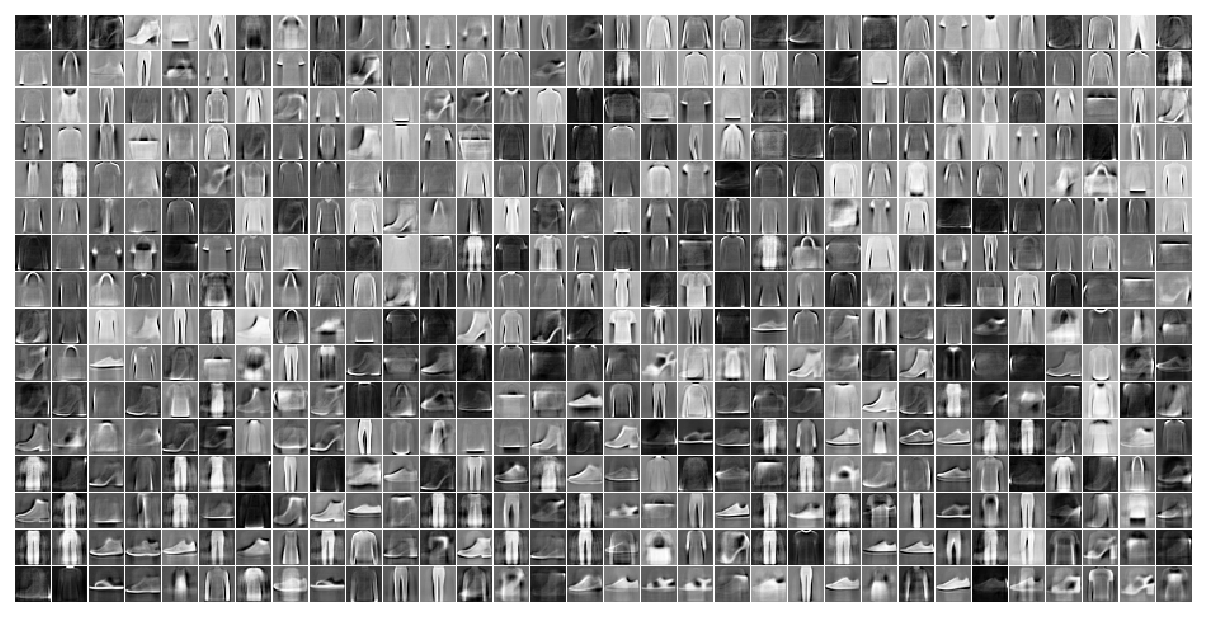

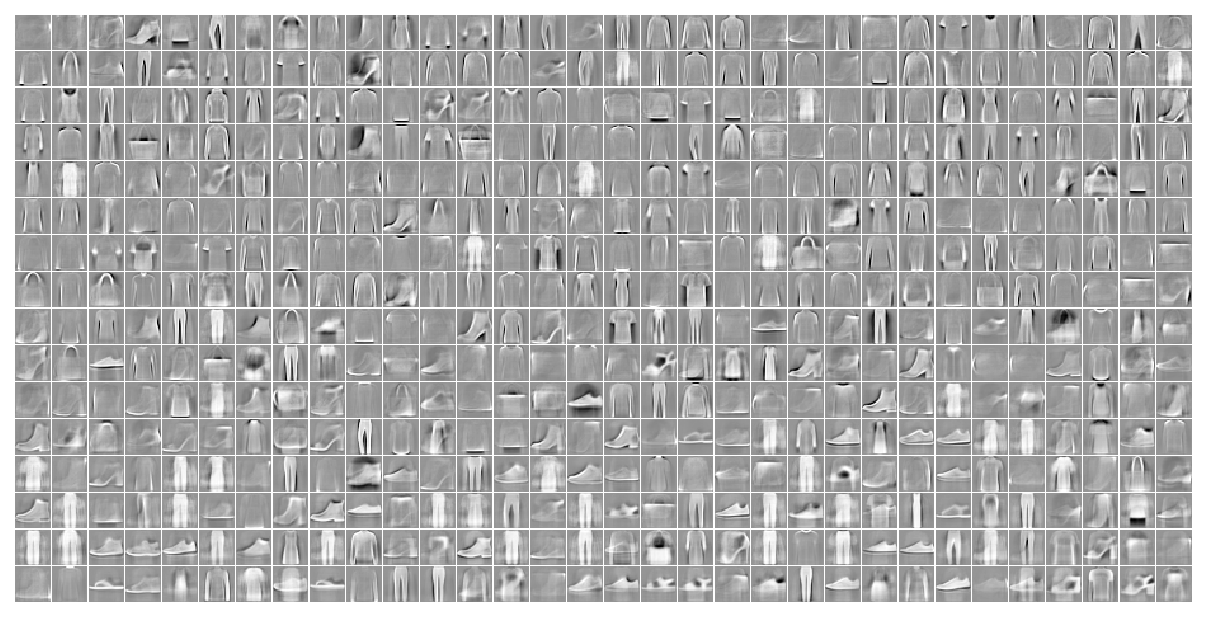

In [23]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:55<00:00, 27.72s/it]


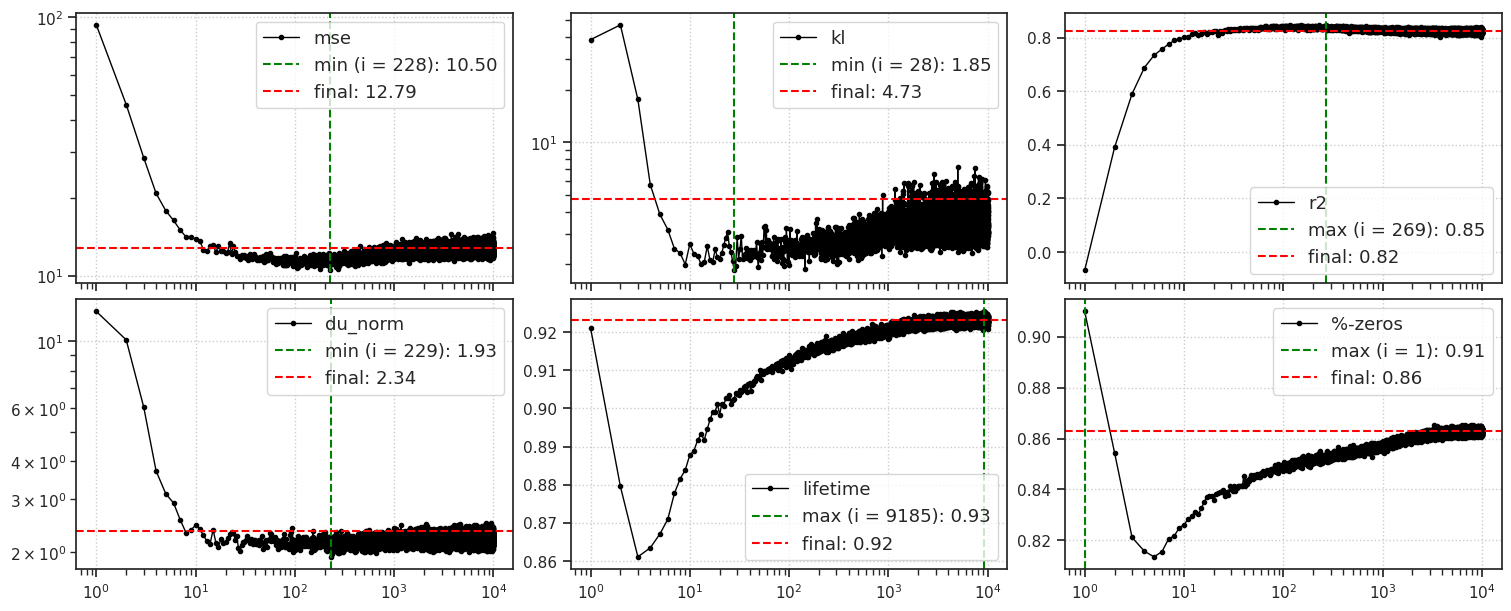

CPU times: user 1min 3s, sys: 3.85 s, total: 1min 7s
Wall time: 1min 7s


In [24]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [25]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:06<00:00,  3.21s/it]


In [26]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [28]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [29]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.8619